In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

In [3]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Saving Apple (AAPL) From 1980 To Dec-2024.csv to Apple (AAPL) From 1980 To Dec-2024.csv
Dataset loaded successfully!
Dataset shape: (11084, 6)


,Date,Open,High,Low,Close,Volume
0,1980-12-12 00:00:00-05:00,0.098834,0.099264,0.098834,0.098834,469033600
1,1980-12-15 00:00:00-05:00,0.094108,0.094108,0.093678,0.093678,175884800
2,1980-12-16 00:00:00-05:00,0.087232,0.087232,0.086802,0.086802,105728000
3,1980-12-17 00:00:00-05:00,0.088951,0.089381,0.088951,0.088951,86441600
4,1980-12-18 00:00:00-05:00,0.091530,0.091959,0.091530,0.091530,73449600


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11084 entries, 0 to 11083
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11084 non-null  object 
 1   Open    11084 non-null  float64
 2   High    11084 non-null  float64
 3   Low     11084 non-null  float64
 4   Close   11084 non-null  float64
 5   Volume  11084 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 519.7+ KB

Missing values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [5]:
# Convert Date to UTC datetime
df['Date'] = pd.to_datetime(
    df['Date'],
    errors='coerce',
    utc=True
)

# Remove timezone information
df['Date'] = df['Date'].dt.tz_localize(None)

# Remove invalid dates
df = df.dropna(subset=['Date']).copy()

# Sort chronologically
df = df.sort_values('Date').reset_index(drop=True)

print("Date range:")
print("Start:", df['Date'].min())
print("End:", df['Date'].max())

print("\nDataset shape:", df.shape)
print("\nDate data type:", df['Date'].dtype)

Date range:
Start: 1980-12-12 05:00:00
End: 2024-11-29 05:00:00

Dataset shape: (11084, 6)

Date data type: datetime64[ns]


In [6]:
df_final = df[
    (df['Date'] >= '2015-01-01') &
    (df['Date'] <= '2024-12-31')
].copy()

df_final = df_final.sort_values(
    'Date'
).reset_index(drop=True)

print("Final dataset shape:", df_final.shape)

print("Start date:", df_final['Date'].min())
print("End date:", df_final['Date'].max())

Final dataset shape: (2495, 6)
Start date: 2015-01-02 05:00:00
End date: 2024-11-29 05:00:00


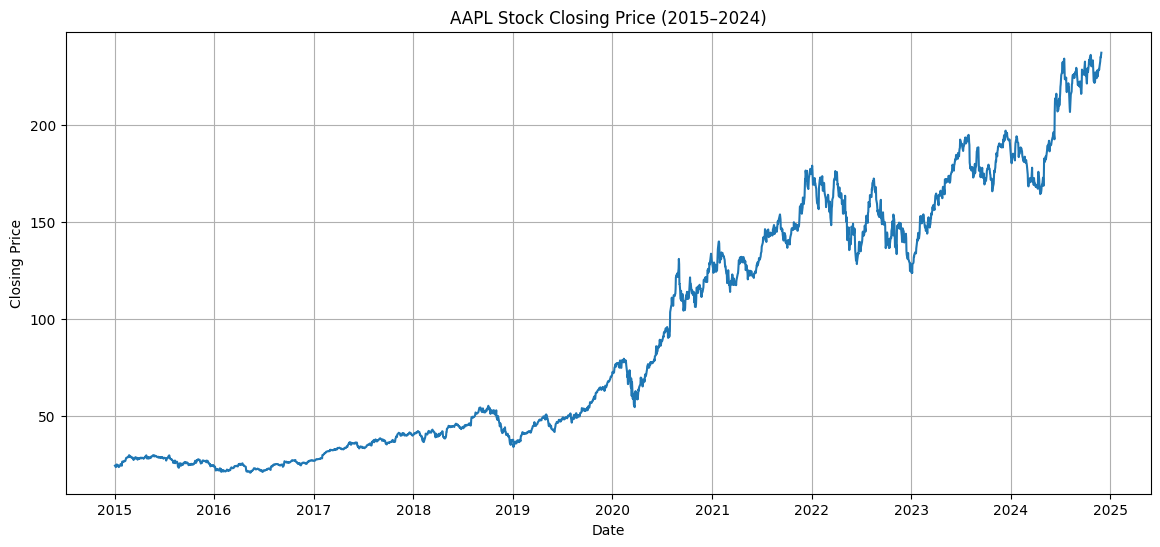

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_final['Date'],
    df_final['Close']
)

plt.title('AAPL Stock Closing Price (2015–2024)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)

plt.show()

In [8]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

data = df_final[features].values

print("Selected features:")
print(features)

print("\nData shape:", data.shape)

Selected features:
['Open', 'High', 'Low', 'Close', 'Volume']

Data shape: (2495, 5)


In [9]:
train_size = int(len(data) * 0.80)
val_size = int(len(data) * 0.10)

train_data = data[:train_size]

val_data = data[
    train_size:train_size + val_size
]

test_data = data[
    train_size + val_size:
]

print("Training records:", len(train_data))
print("Validation records:", len(val_data))
print("Testing records:", len(test_data))

Training records: 1996
Validation records: 249
Testing records: 250


In [10]:
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit scaler ONLY on training data
train_scaled = scaler.fit_transform(train_data)

# Use the same scaler for validation and test
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

print("Normalization completed.")

Normalization completed.


In [11]:
sequence_length = 60

def create_sequences(data, sequence_length):
    X = []
    y = []

    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])

        # Close price is column index 3
        y.append(data[i, 3])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(
    train_scaled,
    sequence_length
)

X_val, y_val = create_sequences(
    val_scaled,
    sequence_length
)

X_test, y_test = create_sequences(
    test_scaled,
    sequence_length
)

print("Sequence shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Sequence shapes:
X_train: (1936, 60, 5)
y_train: (1936,)
X_val: (189, 60, 5)
y_val: (189,)
X_test: (190, 60, 5)
y_test: (190,)


In [12]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(50),

    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,251 (43.95 KB)

 Trainable params: 11,251 (43.95 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0076 - val_loss: 0.0035
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0022 - val_loss: 6.6727e-04
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0020 - val_loss: 7.1412e-04
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0019 - val_loss: 7.3278e-04
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0017 - val_loss: 7.1498e-04
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0016 - val_loss: 7.2443e-04
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 9/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0015 - val_loss: 8.2618e-04
Epoch 10/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0015 - val_loss: 5.0125e-04
Epoch 11/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 12/20
61/61 ━━━━━━━━━━━━━━━━━

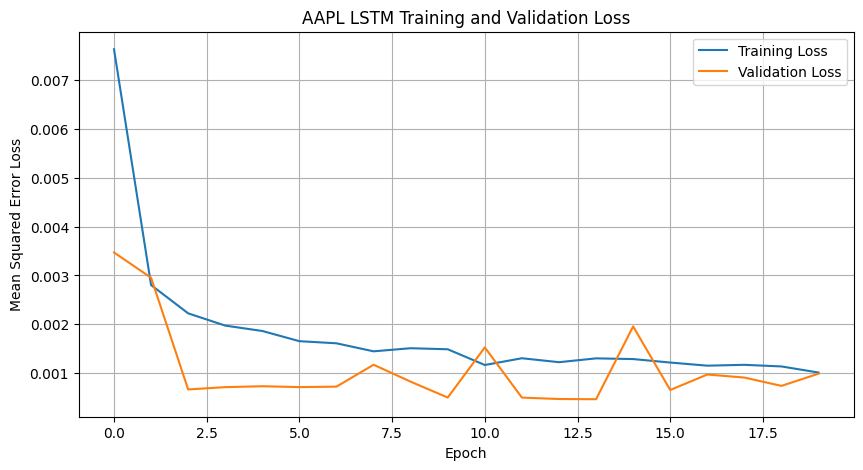

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('AAPL LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')

plt.legend()
plt.grid(True)

plt.show()

In [15]:
predictions_scaled = model.predict(
    X_test,
    verbose=0
)

print("Test prediction completed.")
print("Number of predictions:", len(predictions_scaled))

Test prediction completed.
Number of predictions: 190


In [16]:
# Convert predicted values back to original price scale

dummy_pred = np.zeros((len(predictions_scaled), 5))

# Close is the 4th feature (index 3)
dummy_pred[:, 3] = predictions_scaled[:, 0]

predictions = scaler.inverse_transform(
    dummy_pred
)[:, 3]


# Convert actual test values back to original scale
dummy_actual = np.zeros((len(y_test), 5))

dummy_actual[:, 3] = y_test

actual_prices = scaler.inverse_transform(
    dummy_actual
)[:, 3]

print("Actual price range:")
print(f"${actual_prices.min():.2f} - ${actual_prices.max():.2f}")

print("\nPredicted price range:")
print(f"${predictions.min():.2f} - ${predictions.max():.2f}")

Actual price range:
$164.41 - $237.33

Predicted price range:
$163.71 - $225.37


In [17]:
# Calculate evaluation metrics

mae = mean_absolute_error(
    actual_prices,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predictions
    )
)

mape = np.mean(
    np.abs(
        (actual_prices - predictions)
        / actual_prices
    )
) * 100


print("====================================")
print("       FINAL LSTM RESULTS")
print("====================================")

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.4f}%")

       FINAL LSTM RESULTS
MAE  : 7.0307
RMSE : 8.3258
MAPE : 3.3010%


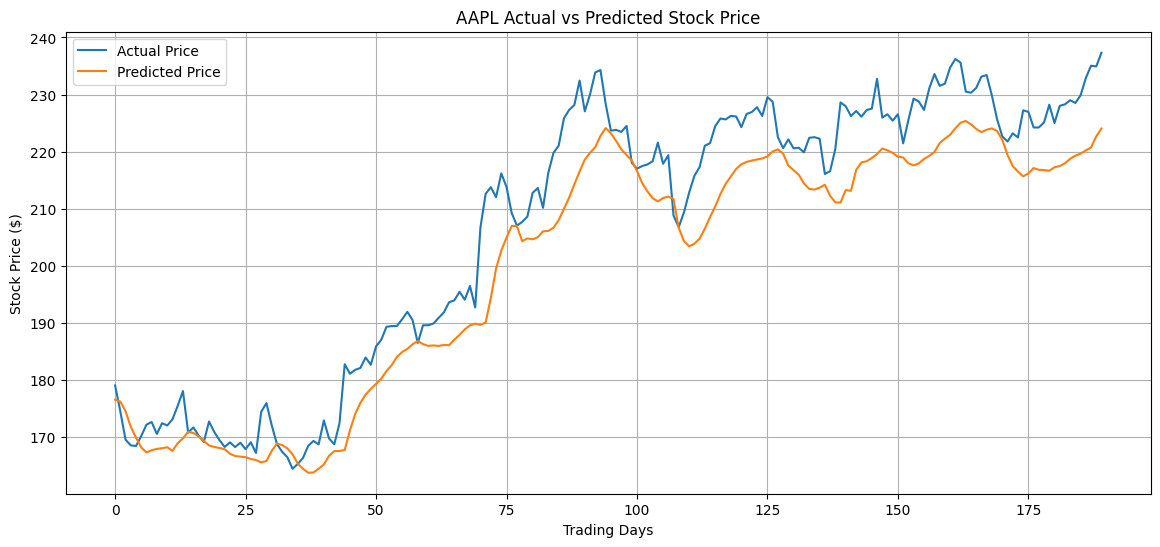

In [18]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_prices,
    label='Actual Price'
)

plt.plot(
    predictions,
    label='Predicted Price'
)

plt.title('AAPL Actual vs Predicted Stock Price')
plt.xlabel('Trading Days')
plt.ylabel('Stock Price ($)')

plt.legend()
plt.grid(True)

plt.show()

In [19]:
# Predict the next trading day's AAPL closing price

sequence_length = 60

# Get the most recent 60 trading days
latest_data = data[-sequence_length:]

# Scale using the SAME scaler fitted on training data
latest_scaled = scaler.transform(latest_data)

# Reshape for LSTM: (samples, timesteps, features)
latest_scaled = latest_scaled.reshape(
    1,
    sequence_length,
    len(features)
)

# Predict next day's normalized Close price
next_day_scaled = model.predict(
    latest_scaled,
    verbose=0
)

# Convert prediction back to actual price
dummy_next = np.zeros((1, 5))
dummy_next[0, 3] = next_day_scaled[0, 0]

next_day_price = scaler.inverse_transform(
    dummy_next
)[0, 3]

print("====================================")
print("     NEXT-DAY AAPL PREDICTION")
print("====================================")
print(f"Last available date : {df_final['Date'].iloc[-1].date()}")
print(f"Last actual close   : ${df_final['Close'].iloc[-1]:.2f}")
print(f"Predicted next close: ${next_day_price:.2f}")

     NEXT-DAY AAPL PREDICTION
Last available date : 2024-11-29
Last actual close   : $237.33
Predicted next close: $225.29


In [20]:
model.save("AAPL_LSTM_Final.keras")
print("Model saved successfully!")

Model saved successfully!


In [21]:
print("==========================================")
print("       AAPL LSTM FINAL SUMMARY")
print("==========================================")

print("Dataset period      : 2015–2024")
print("Number of records   :", len(df_final))
print("Input features      :", ", ".join(features))
print("Sequence length     : 60 trading days")
print("LSTM units          : 50")
print("Dropout             : 0.2")
print("Epochs              : 20")
print("Batch size          : 32")
print("Optimizer           : Adam")
print("------------------------------------------")
print(f"MAE                 : {mae:.4f}")
print(f"RMSE                : {rmse:.4f}")
print(f"MAPE                : {mape:.4f}%")
print("------------------------------------------")
print(f"Last actual Close   : ${df_final['Close'].iloc[-1]:.2f}")
print(f"Next-day prediction : ${next_day_price:.2f}")
print("==========================================")

       AAPL LSTM FINAL SUMMARY
Dataset period      : 2015–2024
Number of records   : 2495
Input features      : Open, High, Low, Close, Volume
Sequence length     : 60 trading days
LSTM units          : 50
Dropout             : 0.2
Epochs              : 20
Batch size          : 32
Optimizer           : Adam
------------------------------------------
MAE                 : 7.0307
RMSE                : 8.3258
MAPE                : 3.3010%
------------------------------------------
Last actual Close   : $237.33
Next-day prediction : $225.29


In [22]:
import os

print("Files currently available:")
print(os.listdir())

Files currently available:
['.config', 'AAPL_LSTM_Final.keras', 'Apple (AAPL) From 1980 To Dec-2024.csv', 'sample_data']


In [23]:
from tensorflow.keras.models import load_model

model = load_model("AAPL_LSTM_Final.keras")

print("LSTM model loaded successfully!")
model.summary()

LSTM model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,755 (131.86 KB)

 Trainable params: 11,251 (43.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,504 (87.91 KB)

In [25]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import MinMaxScaler

# Load original dataset
df = pd.read_csv("Apple (AAPL) From 1980 To Dec-2024.csv")

# Process dates exactly as before
df['Date'] = pd.to_datetime(
    df['Date'],
    errors='coerce',
    utc=True
)
df['Date'] = df['Date'].dt.tz_localize(None)

df = df.dropna(subset=['Date']).copy()
df = df.sort_values('Date').reset_index(drop=True)

# Select 2015–2024
df_final = df[
    (df['Date'] >= '2015-01-01') &
    (df['Date'] <= '2024-12-31')
].copy()

df_final = df_final.sort_values('Date').reset_index(drop=True)

# Same five features used to train the LSTM
features = ['Open', 'High', 'Low', 'Close', 'Volume']

data = df_final[features].values

# Same 80% training split
train_size = int(len(data) * 0.80)

train_data = data[:train_size]

# Recreate scaler using ONLY training data
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_data)

# Save scaler
joblib.dump(scaler, "AAPL_MinMaxScaler.pkl")

print("Scaler recreated successfully!")
print("Scaler saved as: AAPL_MinMaxScaler.pkl")
print("Training records used:", len(train_data))

Scaler recreated successfully!
Scaler saved as: AAPL_MinMaxScaler.pkl
Training records used: 1996


In [26]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Create project folders
project_path = '/content/drive/MyDrive/AAPL-LSTM-Stock-Prediction'
model_path = os.path.join(project_path, 'models')

os.makedirs(model_path, exist_ok=True)

# Copy model and scaler to Google Drive
shutil.copy(
    '/content/AAPL_LSTM_Final.keras',
    os.path.join(model_path, 'AAPL_LSTM_Final.keras')
)

shutil.copy(
    '/content/AAPL_MinMaxScaler.pkl',
    os.path.join(model_path, 'AAPL_MinMaxScaler.pkl')
)

print("Files saved permanently to Google Drive!")
print("\nLocation:")
print(model_path)

print("\nFiles:")
print(os.listdir(model_path))

Mounted at /content/drive
Files saved permanently to Google Drive!

Location:
/content/drive/MyDrive/AAPL-LSTM-Stock-Prediction/models

Files:
['AAPL_LSTM_Final.keras', 'AAPL_MinMaxScaler.pkl']


In [27]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Create project folders
project_path = '/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction'
model_path = os.path.join(project_path, 'models')

os.makedirs(model_path, exist_ok=True)

# Copy model and scaler to Google Drive
shutil.copy(
    '/content/AAPL_LSTM_Final.keras',
    os.path.join(model_path, 'AAPL_LSTM_Final.keras')
)

shutil.copy(
    '/content/AAPL_MinMaxScaler.pkl',
    os.path.join(model_path, 'AAPL_MinMaxScaler.pkl')
)

print("Files saved permanently to Google Drive!")
print("\nLocation:")
print(model_path)

print("\nFiles:")
print(os.listdir(model_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files saved permanently to Google Drive!

Location:
/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction/models

Files:
['AAPL_LSTM_Final.keras', 'AAPL_MinMaxScaler.pkl']


In [28]:
# ============================================================
# VERIFY SAVED FINAL MODEL AND SCALER
# ============================================================

import os
import joblib

PROJECT_PATH = "/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction"
MODEL_PATH = os.path.join(PROJECT_PATH, "models", "AAPL_LSTM_Final.keras")
SCALER_PATH = os.path.join(PROJECT_PATH, "models", "AAPL_MinMaxScaler.pkl")

print("==========================================")
print("       SAVED MODEL VERIFICATION")
print("==========================================")

print("Model exists :", os.path.exists(MODEL_PATH))
print("Scaler exists:", os.path.exists(SCALER_PATH))

if os.path.exists(MODEL_PATH):
    print("\nModel file:")
    print(MODEL_PATH)
    print("Model size:", round(os.path.getsize(MODEL_PATH) / (1024 * 1024), 2), "MB")

if os.path.exists(SCALER_PATH):
    print("\nScaler file:")
    print(SCALER_PATH)
    print("Scaler size:", round(os.path.getsize(SCALER_PATH) / 1024, 2), "KB")

print("==========================================")

       SAVED MODEL VERIFICATION
Model exists : True
Scaler exists: True

Model file:
/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction/models/AAPL_LSTM_Final.keras
Model size: 0.15 MB

Scaler file:
/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction/models/AAPL_MinMaxScaler.pkl
Scaler size: 0.86 KB


In [29]:
# ============================================================
# SAVE CURRENT FINAL MODEL + SCALER
# ============================================================

import os
import joblib

PROJECT_PATH = "/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction"
MODEL_DIR = os.path.join(PROJECT_PATH, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

# Save the currently trained model
model.save(os.path.join(MODEL_DIR, "AAPL_LSTM_Final.keras"))

# Save the scaler used during training
joblib.dump(scaler, os.path.join(MODEL_DIR, "AAPL_MinMaxScaler.pkl"))

print("==========================================")
print("       FINAL MODEL SAVED")
print("==========================================")
print("Model :", os.path.join(MODEL_DIR, "AAPL_LSTM_Final.keras"))
print("Scaler:", os.path.join(MODEL_DIR, "AAPL_MinMaxScaler.pkl"))
print("==========================================")

       FINAL MODEL SAVED
Model : /content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction/models/AAPL_LSTM_Final.keras
Scaler: /content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction/models/AAPL_MinMaxScaler.pkl
